In [5]:
#Image Processing (RGB Image)

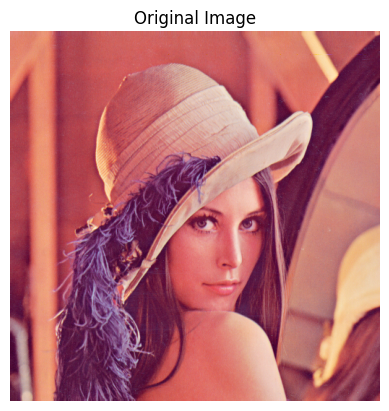

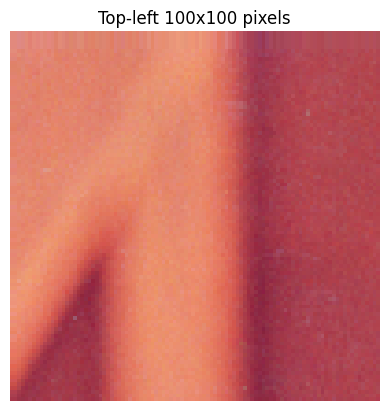

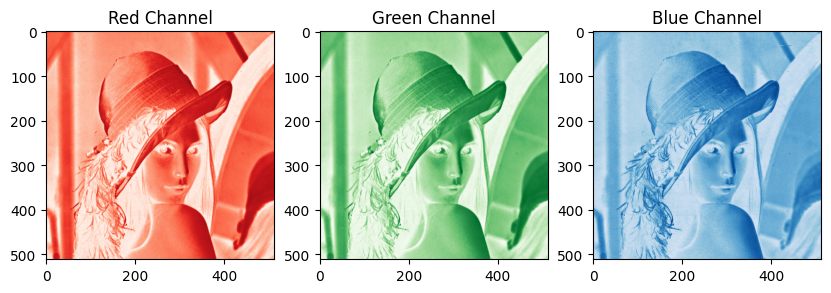

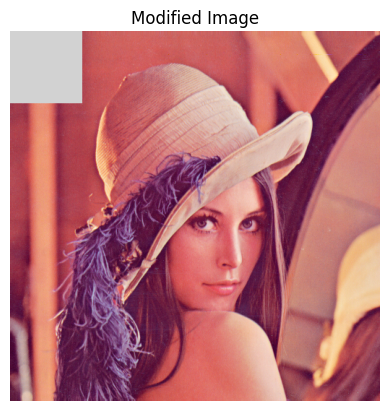

In [9]:
# 1 Read and display image
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np

img= Image.open("/content/Lenna_(test_image).png")

plt.imshow(img)
plt.title("Original Image")
plt.axis("off")
plt.show()

# 2. Top-left 100x100 pixels

img_array = np.array(img)

top_left = img_array[0:100, 0:100]


plt.imshow(top_left)
plt.title("Top-left 100x100 pixels")
plt.axis("off")
plt.show()

#Concept: slicing: [row, column]

# 3. Show R, G, B channels

R = img_array[:, :, 1]
G = img_array[:, :, 1]
B = img_array[:, :, 2]

plt.figure(figsize=(10,4))

plt.subplot(1,3,1)
plt.imshow(R, cmap='Reds')
plt.title("Red Channel")

plt.subplot(1,3,2)
plt.imshow(G, cmap='Greens')
plt.title("Green Channel")

plt.subplot(1,3,3)
plt.imshow(B, cmap='Blues')
plt.title("Blue Channel")

plt.show()

# Modify top 100×100 to 210

modified = img_array.copy()
modified[0:100, 0:100] = 210

plt.imshow(modified)
plt.title("Modified Image")
plt.axis('off')
plt.show()

Exercise 2: Grayscale Image

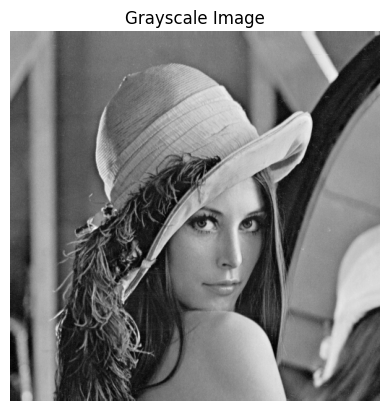

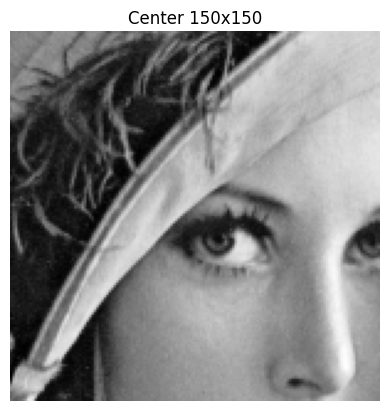

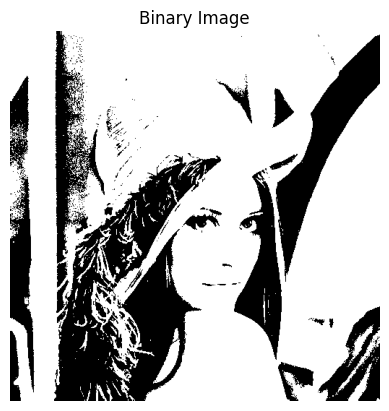

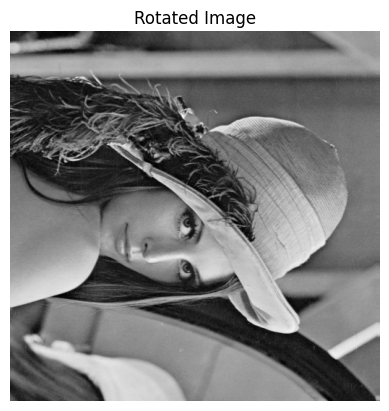

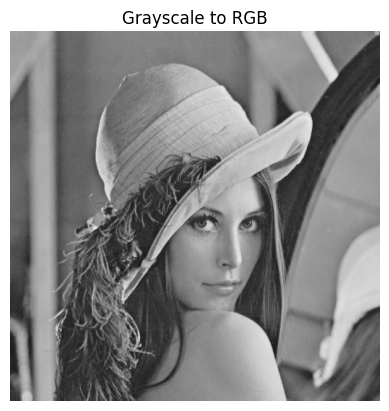

In [14]:
#1. Load grayscale image
gray_img = Image.open("/content/Lenna_(test_image).png").convert('L')

plt.imshow(gray_img, cmap='gray')
plt.title("Grayscale Image")
plt.axis('off')
plt.show()


#2. Middle 150 pixels
gray_array = np.array(gray_img)

h, w = gray_array.shape

center = gray_array[h//2 - 75:h//2 + 75, w//2 - 75:w//2 + 75]

plt.imshow(center, cmap='gray')
plt.title("Center 150x150")
plt.axis('off')
plt.show()

#3. Threshold (Binary Image)
binary = np.where(gray_array < 100, 0, 255)

plt.imshow(binary, cmap='gray')
plt.title("Binary Image")
plt.axis('off')
plt.show()

#4. Rotate 90° clockwise
rotated = gray_img.rotate(-90)

plt.imshow(rotated, cmap='gray')
plt.title("Rotated Image")
plt.axis('off')
plt.show()

#5. Convert grayscale to RGB
rgb_img = np.stack((gray_array,)*3, axis=-1)

plt.imshow(rgb_img)
plt.title("Grayscale to RGB")
plt.axis('off')
plt.show()

Exercise 3: PCA Image Compression

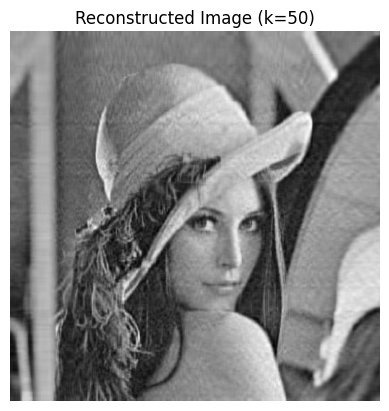

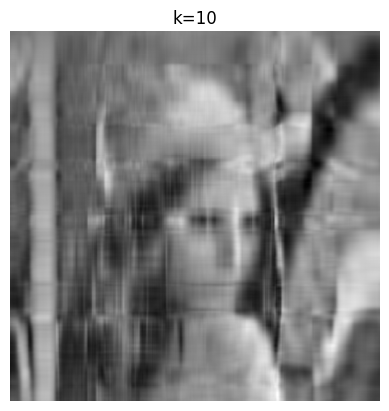

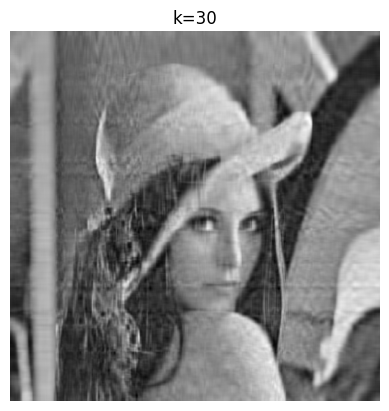

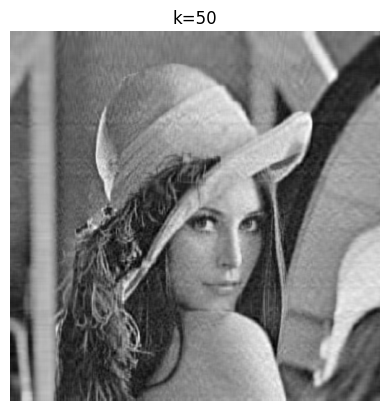

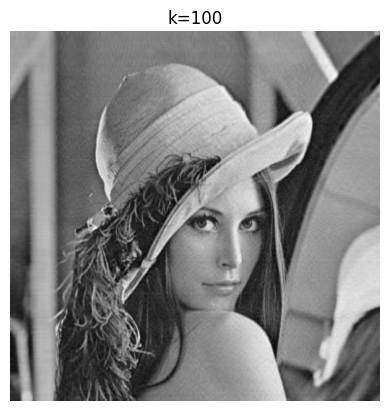

In [23]:
#Load + Standardize
img = Image.open("/content/Lenna_(test_image).png").convert('L')
data = np.array(img, dtype = float)

mean = np.mean(data)
data_centered = data - mean

#Covariance Matrix
cov_matrix = np.cov(data_centered)

#Eigenvalues & Eigenvectors
eigenvalues, eigenvectors = np.linalg.eig(cov_matrix)

# Sort descending
idx = np.argsort(eigenvalues)[::-1]
eigenvalues = eigenvalues[idx]
eigenvectors = eigenvectors[:, idx]

#Choose k (Principal Components)
k = 50  # try different values
eigenvectors_k = eigenvectors[:, :k]

#Transform + Reconstruct
# Compress
compressed = np.dot(eigenvectors_k.T, data_centered)

# Reconstruct
reconstructed = np.dot(eigenvectors_k, compressed) + mean


# Convert to real values
reconstructed = reconstructed.real

#Display Result
plt.imshow(reconstructed, cmap='gray')
plt.title(f"Reconstructed Image (k={k})")
plt.axis('off')
plt.show()

#Try Multiple k values
for k in [10, 30, 50, 100]:
    eigenvectors_k = eigenvectors[:, :k]
    compressed = np.dot(eigenvectors_k.T, data_centered)
    reconstructed = np.dot(eigenvectors_k, compressed) + mean

    # Convert to real values
    reconstructed = reconstructed.real

    plt.imshow(reconstructed, cmap='gray')
    plt.title(f"k={k}")
    plt.axis('off')
    plt.show()
